# nb37 - Texture error analysis: where does the best model still fail?

Slice the test residuals of the current best predictor (7-model ensemble, 0.0444) along every event 'texture' we can compute from the window: pitch-tier region, cell multiplicity, lateral shower width, seed energy fraction, front/back ratio, time spread and coverage, and window contamination (sumE vs predicted energy - no truth used for slicing). For each texture: sigma_eff per quantile bin, overall and within E>17 GeV where the remaining gap to the 0.030-0.035 targets lives. The worst slices tell us what mechanism (teacher-student distillation, spacetime edges, something else) actually targets the residual error.

In [1]:
import os, sys, pathlib
import numpy as np, pandas as pd, uproot, awkward as ak, matplotlib.pyplot as plt
REPO = pathlib.Path(os.environ['REPO_DIR']) if os.environ.get('REPO_DIR') else (
    pathlib.Path.cwd().parent if pathlib.Path.cwd().name == 'notebooks' else pathlib.Path.cwd())
sys.path.insert(0, str(REPO / 'scripts'))
from run_experiments import split, resolution, PITCH, EPS
MB = sorted((REPO / 'data' / 'minimum_bias').glob('*.root'))
OUT = REPO / 'reports' / 'predictions'
FIG = REPO / 'reports' / 'figures'
THRESH = 2.49; W = 4
print(len(MB), 'minbias files')

94 minbias files


In [2]:
TK = ['cell_x','cell_y','energy','cell_energies_front','cell_energies_back',
      'cell_times_front','cell_times_back','imodx','jmody']
AUX = ['sig_flux_prod_vertex_z','sig_flux_eTot']
def event_geom(cc):
    x, yy, e = cc['cell_x'], cc['cell_y'], cc['energy']
    ix, iy = cc['imodx'], cc['jmody']
    seed = int(np.argmax(e))
    pts = np.stack([x, yy], 1)
    pitch = np.full(len(x), np.nan)
    for key in {(int(p), int(q)) for p, q in zip(ix, iy)}:
        sel = (ix == key[0]) & (iy == key[1]); p = pts[sel]
        if len(p) >= 2:
            d = np.sqrt(((p[:, None, :] - p[None, :, :]) ** 2).sum(-1)); d[d == 0] = np.inf
            pitch[sel] = np.median(np.min(d, axis=1))
    fill = np.nanmedian(pitch) if np.isfinite(pitch).any() else 120.0
    pitch[~np.isfinite(pitch)] = fill
    ps = pitch[seed]
    ei = (x - x[seed]) / ps; ej = (yy - yy[seed]) / ps
    di = np.round(ei).astype(int); dj = np.round(ej).astype(int)
    ok = (np.abs(ei - di) < 0.15) & (np.abs(ej - dj) < 0.15)
    return seed, ps, di, dj, ok
F = []
kept = 0
for path in MB:
    with uproot.open(path) as f:
        a = f['clusters_matched'].arrays(TK + AUX, library='ak')
    vz = ak.to_numpy(a['sig_flux_prod_vertex_z']).astype(float)
    et_all = ak.to_numpy(a['sig_flux_eTot']).astype(float)
    for i in np.flatnonzero((vz < 100.0) & (et_all >= 1.0) & (et_all <= 100.0)):
        cc = {k: np.asarray(ak.to_numpy(a[k][i])).astype(float) for k in TK}
        e = cc['energy']
        if len(e) < 3: continue
        seed, ps, di, dj, ok = event_geom(cc)
        if ok.mean() < 0.5 or not ok[seed]: continue
        m = ok & (np.maximum(np.abs(di), np.abs(dj)) <= W) & (e >= THRESH)
        if m.sum() < 1 or not m[seed]: continue
        ew = e[m]; fr = cc['cell_energies_front'][m]; bk = cc['cell_energies_back'][m]
        tf = cc['cell_times_front'][m]
        tf = np.where(np.isfinite(tf) & (tf != 0) & (np.abs(tf) < 1e4), tf, np.nan)
        rdr = np.hypot(di[m], dj[m])
        sumE = ew.sum()
        tpres = np.isfinite(tf)
        F.append(dict(reg=int(np.argmin(np.abs(PITCH - ps))), nc=int(m.sum()),
                      lat=float(np.sqrt((ew * rdr ** 2).sum() / (sumE + EPS))),
                      seedfrac=float(ew.max() / (sumE + EPS)),
                      fb=float(fr.sum() / (bk.sum() + EPS)),
                      tspread=float(np.nanstd(tf)) if tpres.sum() > 1 else 0.0,
                      tcov=float(tpres.mean()), sumE=float(sumE), Etrue=float(et_all[i])))
FD = pd.DataFrame(F)
print('features for', len(FD), 'windows')

features for 72554 windows


In [3]:
a_, b_, t_ = split(len(FD))
TE = FD.iloc[t_].reset_index(drop=True)
preds = []
for p in ['nb32_pred_W4_s0.npy', 'nb32_pred_W4_s1.npy', 'nb32_pred_W4_s2.npy',
          'nb34_pred_pure_s3.npy', 'nb34_pred_pure_s4.npy', 'nb34_pred_cleanaux_s0.npy', 'nb34_pred_cleanaux_s1.npy']:
    fp = OUT / p
    if fp.exists(): preds.append(np.load(fp))
pe = np.stack(preds).mean(0)
assert len(pe) == len(TE), (len(pe), len(TE))
TE['pred'] = pe; TE['r'] = pe / TE.Etrue - 1.0
TE['contam'] = TE.sumE / (TE.pred * 1e3)
print('ensemble of', len(preds), 'models | overall sigma_eff',
      resolution(TE.pred.to_numpy(), TE.Etrue.to_numpy())['sigma_eff'])

ensemble of 7 models | overall sigma_eff 0.0444


## sigma_eff by texture quantile - all events and E>17 GeV

In [4]:
def sliced(df, col, q=4, label=''):
    out = []
    if col == 'reg':
        groups = [(f'R{int(v)}', df[df.reg == v]) for v in sorted(df.reg.unique()) if (df.reg == v).sum() >= 100]
    else:
        edges = np.quantile(df[col], np.linspace(0, 1, q + 1)); edges[-1] += 1e-9
        groups = [(f'{edges[j]:.2f}-{edges[j+1]:.2f}', df[(df[col] >= edges[j]) & (df[col] < edges[j+1])])
                  for j in range(q)]
    for name, g in groups:
        if len(g) < 100: continue
        out.append(dict(texture=col, slice=name, n=len(g),
                        sigma_eff=resolution(g.pred.to_numpy(), g.Etrue.to_numpy())['sigma_eff'],
                        bias=round(float(np.median(g.r)), 4)))
    return out
TEXTURES = ['reg', 'nc', 'lat', 'seedfrac', 'fb', 'tspread', 'tcov', 'contam']
for name, df in [('ALL', TE), ('E>17', TE[TE.Etrue > 17.4])]:
    rows = []
    for t in TEXTURES: rows.extend(sliced(df, t))
    S = pd.DataFrame(rows)
    print(f'===== {name} (n={len(df)}) =====')
    print(S.to_string(index=False))
    if name == 'E>17': SH = S

===== ALL (n=10884) =====
 texture       slice    n  sigma_eff    bias
     reg          R0 1233     0.0701 -0.0033
     reg          R1 2178     0.0609 -0.0049
     reg          R2 3134     0.0392 -0.0056
     reg          R3 3693     0.0360 -0.0036
     reg          R4  646     0.0419 -0.0014
      nc  5.00-34.00 2440     0.0428 -0.0030
      nc 34.00-47.00 2998     0.0419 -0.0042
      nc 47.00-64.00 2095     0.0511 -0.0048
      nc 64.00-81.00 3351     0.0432 -0.0051
     lat   0.21-1.37 2721     0.0320 -0.0036
     lat   1.37-2.02 2721     0.0390 -0.0048
     lat   2.02-2.59 2721     0.0464 -0.0054
     lat   2.59-3.95 2721     0.0656 -0.0029
seedfrac   0.07-0.28 2721     0.0783 -0.0063
seedfrac   0.28-0.39 2721     0.0451 -0.0034
seedfrac   0.39-0.53 2721     0.0358 -0.0046
seedfrac   0.53-0.96 2721     0.0302 -0.0039
      fb   0.00-0.38 2721     0.0323 -0.0052
      fb   0.38-0.57 2721     0.0402 -0.0042
      fb   0.57-0.88 2721     0.0479 -0.0042
      fb   0.88-5.12 2721    

texture spread at E>17 (worst slice - best slice):
texture
contam      0.0409
reg         0.0370
seedfrac    0.0364
lat         0.0288
fb          0.0266
tcov        0.0210
tspread     0.0149
nc          0.0108


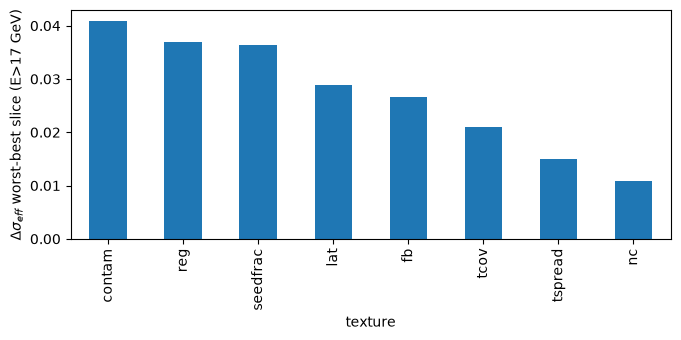

In [5]:
worst = SH.loc[SH.groupby('texture').sigma_eff.idxmax()]
best = SH.loc[SH.groupby('texture').sigma_eff.idxmin()]
spread = (worst.set_index('texture').sigma_eff - best.set_index('texture').sigma_eff).sort_values(ascending=False)
print('texture spread at E>17 (worst slice - best slice):')
print(spread.to_string())
fig, ax = plt.subplots(figsize=(7, 3.5))
spread.plot.bar(ax=ax)
ax.set_ylabel(r'$\Delta\sigma_{eff}$ worst-best slice (E>17 GeV)')
plt.tight_layout(); plt.savefig(FIG / 'fig11_texture_errors.png', dpi=150); plt.show()

## Reading
A large worst-minus-best spread on a texture means that texture indexes a failure mode worth attacking; a flat spread means the model already treats that dimension uniformly. `contam` spread reproduces the known pileup-dominance result (nb28 Phase 1); the interesting question is which OTHER texture still carries spread at E>17 GeV after all nb28-35 improvements - that is the axis the next mechanism (teacher-student, spacetime edges, region-specific handling) has to move.